In [22]:
# 1. Importer les bibliothèques nécessaires
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
from rasterio.transform import Affine
import pandas as pd

In [2]:
# 2. Définir le chemin d'accès au fichier
# Assurez-vous que ce chemin est correct et que le fichier est bien à cet emplacement
file_path = r"G:\Amibatec\Updated2025\RF\Diversity\imageToDrive_meanModel_Diversity_RF.tif"

Informations du raster :
Dimensions : 8016x3919
Système de coordonnées de référence (CRS) : EPSG:4326
Nombre de bandes : 1
------------------------------


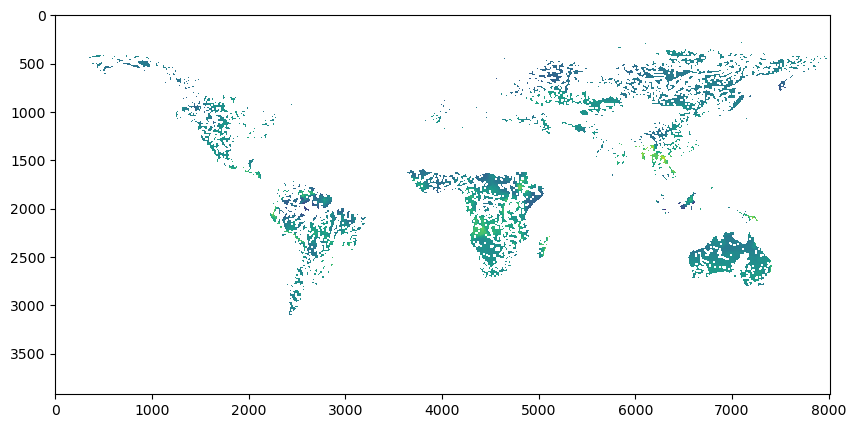

In [23]:
# 3. Ouvrir et lire le raster
# L'utilisation de 'with' garantit que le fichier est correctement fermé après utilisation
with rasterio.open(file_path) as src:
    # Lire la première bande du raster (la plupart des rasters ont au moins une bande)
    raster_data = src.read(1)

    # Afficher les informations de base sur le raster
    print("Informations du raster :")
    print(f"Dimensions : {src.width}x{src.height}")
    print(f"Système de coordonnées de référence (CRS) : {src.crs}")
    print(f"Nombre de bandes : {src.count}")
    print("-" * 30)
    
    # Afficher le raster
    plt.figure(figsize=(10, 10))  # Ajuster la taille de la figure pour un meilleur affichage
    show(raster_data, cmap='viridis') # 'viridis' est une palette de couleurs courante
    plt.show()

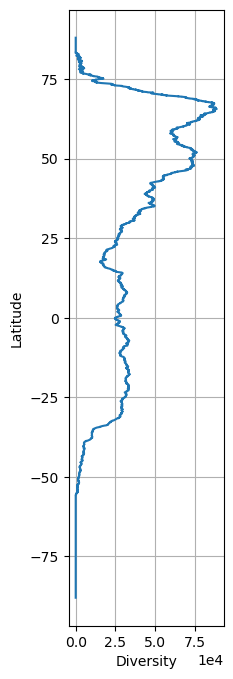

In [24]:
# 4. Cumul des valeurs de pixels par degré de latitude
with rasterio.open(file_path) as src:
    # Lire la première bande du raster
    raster_data = src.read(1)

    # Gérer les valeurs NaN en les remplaçant par zéro
    raster_data[np.isnan(raster_data)] = 0

    # 4. Calculer le cumul des valeurs de pixels par ligne
    sums_per_latitude = np.sum(raster_data, axis=1)

    # 5. Générer les coordonnées de latitude pour l'axe Y
    # On récupère les coordonnées de chaque ligne du raster pour obtenir la latitude
    latitudes = [src.xy(row, 0)[1] for row in np.arange(src.height)]
    
    # Inverser les listes pour un affichage correct (latitudes les plus basses en bas)
    latitudes_reversed = latitudes[::-1]
    sums_reversed = sums_per_latitude[::-1]

    # 6. Créer et afficher le graphique
    plt.figure(figsize=(2, 8))
    
    plt.plot(sums_reversed, latitudes_reversed)
    plt.locator_params(axis='x', nbins=4)
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    
    plt.xlabel('Diversity')
    plt.ylabel('Latitude')
    
    plt.grid(True)
    
    plt.show()

In [26]:
# Exporter en CSV
df_latitudes = pd.DataFrame({
'Latitude': latitudes_reversed,
'Somme des pixels': sums_reversed
})
output_csv_lat = r"G:\Amibatec\Updated2025\RF\Diversity\CumulDiversityByLatitude.csv"
df_latitudes.to_csv(output_csv_lat, index=False)

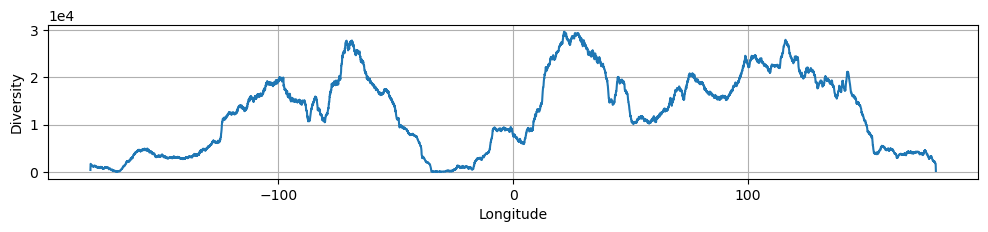

In [30]:
# 5. Cumul des valeurs de pixels par degré de longitude
with rasterio.open(file_path) as src:
    # Lire la première bande du raster
    raster_data = src.read(1)

    # Gérer les valeurs NaN en les remplaçant par zéro
    raster_data[np.isnan(raster_data)] = 0

    # 4. Calculer le cumul des valeurs de pixels par colonne (longitude)
    # L'argument axis=0 indique de sommer le long de l'axe vertical (les lignes)
    sums_per_longitude = np.sum(raster_data, axis=0)

    # 5. Générer les coordonnées de longitude pour l'axe X
    # On récupère les coordonnées de chaque colonne du raster pour obtenir la longitude
    longitudes = [src.xy(0, col)[0] for col in np.arange(src.width)]

    # 6. Créer et afficher le graphique
    plt.figure(figsize=(12, 2))

    # Le graphique sera cette fois-ci horizontal :
    # Longitudes sur l'axe X et sommes sur l'axe Y
    plt.plot(longitudes, sums_per_longitude)
    plt.locator_params(axis='x', nbins=4)
    plt.locator_params(axis='y', nbins=6)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.xlabel('Longitude')
    plt.ylabel('Diversity')

    plt.grid(True)

    plt.show()

In [29]:
# Exporter en CSV
df_longitudes = pd.DataFrame({
'Longitude': longitudes,
'Somme des pixels': sums_per_longitude
})
output_csv_lon = r"G:\Amibatec\Updated2025\RF\Diversity\CumulDiversityByLongitudes.csv"
df_longitudes.to_csv(output_csv_lon, index=False)